In [1]:
# %% Cell 1: imports
import sys, torch, numpy as np
sys.path.append('..'); sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from backbones.backbones import get_resnet50, get_vit, get_clip
from img_prep.make_subset import load_stl10
from img_prep.transforms import to_common_224, resnet_normalize, vit_normalize, clip_normalize
from img_prep.adain import AdaINStyleTransfer
from img_prep.make_cue_conflicts import build_conflict_plan, rejection_rule, CLASS_PAIRS
from evaluations.evaluate_bias import shape_texture_counts, extract_features_from_tensors
import open_clip, torch.nn as nn
import matplotlib.pyplot as plt

set_seed(6304)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
# %% Cell 2: load the 500-image subset
subset_ids = load_results("../results/subset_ids.json")
test_idx = subset_ids["test_subset_indices"]
test_ds = load_stl10(split='test')
class_names = ['airplane','bird','car','cat','deer','dog','horse','monkey','ship','truck']

# pre-load all 500 images once as [0,1] 224x224 tensors
subset_imgs = torch.stack([to_common_224(test_ds[i][0]) for i in test_idx])
subset_labels = np.array([test_ds[i][1] for i in test_idx])
print(subset_imgs.shape, subset_labels.shape)

torch.Size([500, 3, 224, 224]) (500,)


In [3]:
# %% Cell 3: build the conflict plan (seeded, saved)
plan = build_conflict_plan(subset_labels, class_names, n_per_direction=20, seed=6304)
print(f"{len(plan)} planned conflicts across {len(CLASS_PAIRS)} pairs x 2 directions")
save_results({"seed": 6304, "plan": plan}, "../results/cue_conflict_plan.json")

200 planned conflicts across 5 pairs x 2 directions


In [4]:
# %% Cell 4: generate conflicts at both alphas, apply the rejection rule
adain = AdaINStyleTransfer("../../datasets/adain_weights/vgg_normalised.pth",
                            "../../datasets/adain_weights/decoder.pth", device=device)

content_batch = torch.stack([subset_imgs[p["content_pos"]] for p in plan])
style_batch   = torch.stack([subset_imgs[p["style_pos"]]   for p in plan])

generated = {}
for alpha in [0.7, 1.0]:
    outs = []
    for i in range(0, len(plan), 32):                      # batch to fit in memory
        outs.append(adain(content_batch[i:i+32], style_batch[i:i+32], alpha=alpha).cpu())
    stylized = torch.cat(outs)
    keep, corr, std, change = rejection_rule(stylized.to(device), content_batch.to(device))
    generated[alpha] = {"images": stylized, "keep": keep}
    print(f"alpha={alpha}: accepted {keep.sum()} / {len(keep)}  (rejected {(~keep).sum()})")

alpha=0.7: accepted 200 / 200  (rejected 0)
alpha=1.0: accepted 200 / 200  (rejected 0)


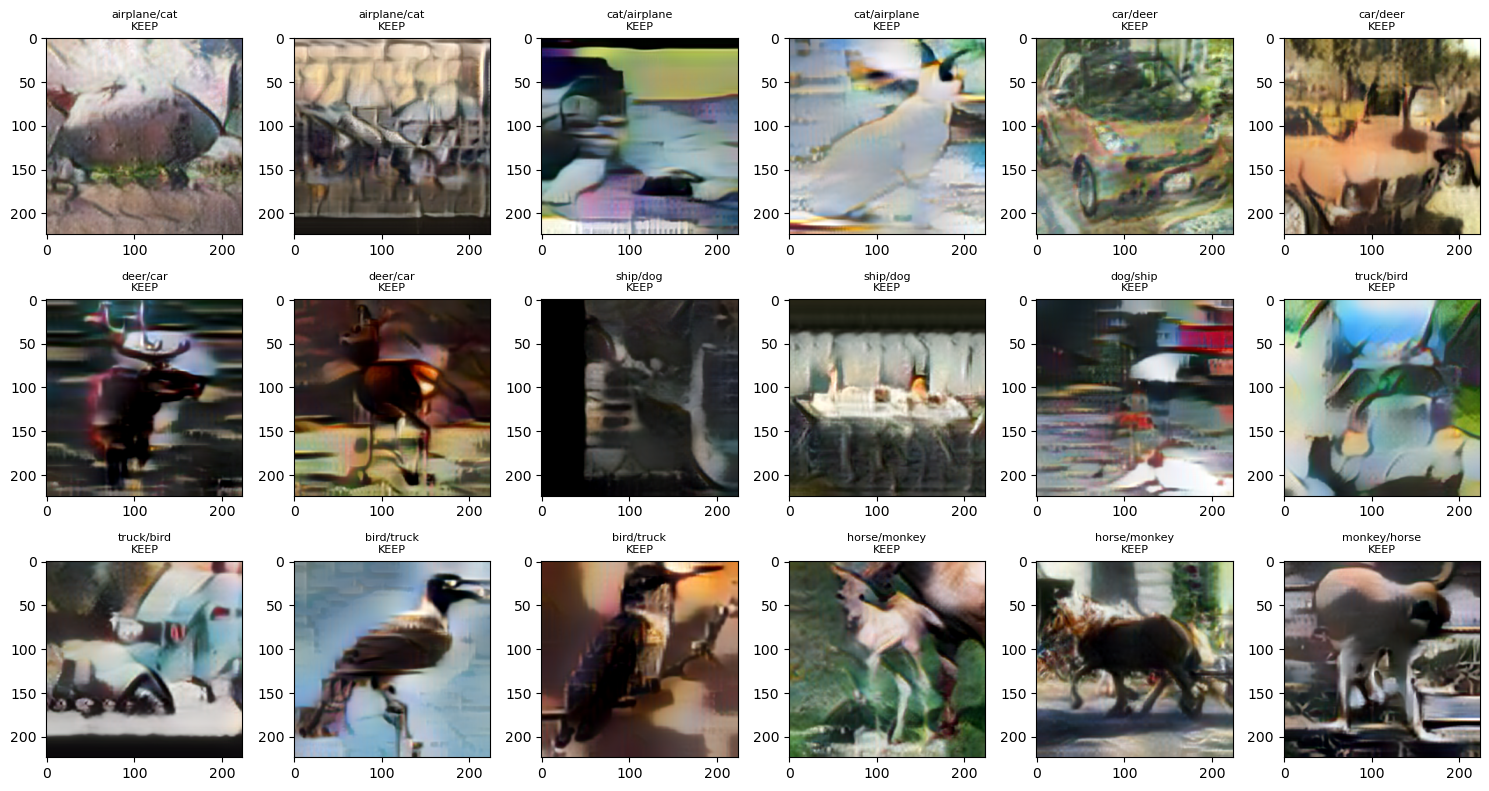

In [5]:
# %% Cell 5: 
alpha_show = 1.0
imgs = generated[alpha_show]["images"]
fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for j, ax in enumerate(axes.flat):
    idx = j * 11 % len(plan)
    ax.imshow(imgs[idx].permute(1, 2, 0).numpy())
    p = plan[idx]
    status = "KEEP" if generated[alpha_show]["keep"][idx] else "REJECT"
    ax.set_title(f"{class_names[p['shape_label']]}/{class_names[p['texture_label']]}\n{status}", fontsize=8)
plt.tight_layout()
fig.savefig("../../report/figures/cue_conflict_samples.png", dpi=200, bbox_inches='tight')
plt.show()

In [6]:
# %% Cell 6: all four models on the accepted conflicts
resnet, _ = get_resnet50(); vit, _ = get_vit(); clip_model, _ = get_clip()
tokenizer = open_clip.get_tokenizer('ViT-B-32')

def load_head(name, in_dim):
    head = nn.Linear(in_dim, 10).to(device)
    head.load_state_dict(torch.load(f"../../datasets/cache/{name}_head.pth", map_location=device))
    head.eval(); return head

heads = {"resnet50": load_head("resnet50", 2048),
         "vit_b16": load_head("vit_b16", 768),
         "clip_head": load_head("clip_head", 512)}

backbones_info = [("resnet50", resnet, resnet_normalize, "resnet_or_vit"),
                  ("vit_b16", vit, vit_normalize, "resnet_or_vit"),
                  ("clip", clip_model, clip_normalize, "clip")]

results = {"step": "shape_texture", "seed": 6304, "alphas": {}}

for alpha in [0.7, 1.0]:
    keep = generated[alpha]["keep"]
    imgs_kept = generated[alpha]["images"][keep]
    plan_kept = [p for p, k in zip(plan, keep) if k]
    shape_labels = np.array([p["shape_label"] for p in plan_kept])
    texture_labels = np.array([p["texture_label"] for p in plan_kept])

    results["alphas"][str(alpha)] = {
        "n_accepted": int(keep.sum()), "n_rejected": int((~keep).sum()), "models": {}
    }

    for name, model, norm_fn, mtype in backbones_info:
        feats = extract_features_from_tensors(model, imgs_kept, norm_fn, model_type=mtype, device=device)

        if name == "clip":
            with torch.no_grad():
                logits = heads["clip_head"](torch.tensor(feats, dtype=torch.float32).to(device))
                preds = logits.argmax(1).cpu().numpy()
            results["alphas"][str(alpha)]["models"]["clip_head"] = shape_texture_counts(preds, shape_labels, texture_labels)

            # zero-shot on the same images
            batch = torch.stack([clip_normalize(x) for x in imgs_kept]).to(device)
            prompts = [f"a photo of a {c}." for c in class_names]
            with torch.no_grad():
                tf_ = clip_model.encode_text(tokenizer(prompts).to(device))
                tf_ = tf_ / tf_.norm(dim=-1, keepdim=True)
                imf = clip_model.encode_image(batch)
                imf = imf / imf.norm(dim=-1, keepdim=True)
                zs_preds = (clip_model.logit_scale.exp() * imf @ tf_.T).argmax(1).cpu().numpy()
            results["alphas"][str(alpha)]["models"]["clip_zeroshot"] = shape_texture_counts(zs_preds, shape_labels, texture_labels)
        else:
            with torch.no_grad():
                logits = heads[name](torch.tensor(feats, dtype=torch.float32).to(device))
                preds = logits.argmax(1).cpu().numpy()
            results["alphas"][str(alpha)]["models"][name] = shape_texture_counts(preds, shape_labels, texture_labels)

    print(f"--- alpha={alpha} ---")
    for m, r in results["alphas"][str(alpha)]["models"].items():
        print(f"  {m}: shape_bias {r['shape_bias_pct']:.1f}%  coverage {r['coverage_pct']:.1f}%  "
              f"(shape {r['n_shape']}, texture {r['n_texture']}, other {r['n_other']})")

--- alpha=0.7 ---
  resnet50: shape_bias 85.8%  coverage 60.0%  (shape 103, texture 17, other 80)
  vit_b16: shape_bias 94.8%  coverage 77.5%  (shape 147, texture 8, other 45)
  clip_head: shape_bias 97.1%  coverage 69.0%  (shape 134, texture 4, other 62)
  clip_zeroshot: shape_bias 98.7%  coverage 77.0%  (shape 152, texture 2, other 46)
--- alpha=1.0 ---
  resnet50: shape_bias 40.5%  coverage 37.0%  (shape 30, texture 44, other 126)
  vit_b16: shape_bias 81.4%  coverage 51.0%  (shape 83, texture 19, other 98)
  clip_head: shape_bias 86.3%  coverage 47.5%  (shape 82, texture 13, other 105)
  clip_zeroshot: shape_bias 85.2%  coverage 54.0%  (shape 92, texture 16, other 92)


In [7]:
# %% Cell 7: save
save_results(results, "../results/shape_texture.json")

In [8]:
# %% Cell 8: informative cue-conflict examples (manual's required evidence)
alpha_ex = 1.0   # the interesting one — this is where models actually disagree
keep = generated[alpha_ex]["keep"]
imgs_kept = generated[alpha_ex]["images"][keep]
plan_kept = [p for p, k in zip(plan, keep) if k]
shape_labels = np.array([p["shape_label"] for p in plan_kept])
texture_labels = np.array([p["texture_label"] for p in plan_kept])

# collect every model's per-image prediction on the same accepted conflicts
all_preds = {}
for name, model, norm_fn, mtype in backbones_info:
    feats = extract_features_from_tensors(model, imgs_kept, norm_fn, model_type=mtype, device=device)
    if name == "clip":
        with torch.no_grad():
            all_preds["clip_head"] = heads["clip_head"](
                torch.tensor(feats, dtype=torch.float32).to(device)).argmax(1).cpu().numpy()
        batch = torch.stack([clip_normalize(x) for x in imgs_kept]).to(device)
        with torch.no_grad():
            tf_ = clip_model.encode_text(tokenizer([f"a photo of a {c}." for c in class_names]).to(device))
            tf_ = tf_ / tf_.norm(dim=-1, keepdim=True)
            imf = clip_model.encode_image(batch)
            imf = imf / imf.norm(dim=-1, keepdim=True)
            all_preds["clip_zeroshot"] = (clip_model.logit_scale.exp() * imf @ tf_.T).argmax(1).cpu().numpy()
    else:
        with torch.no_grad():
            all_preds[name] = heads[name](
                torch.tensor(feats, dtype=torch.float32).to(device)).argmax(1).cpu().numpy()

model_order = ["resnet50", "vit_b16", "clip_head", "clip_zeroshot"]

def verdict(pred, s, t):
    """Label what each prediction followed: shape, texture, or neither."""
    if pred == s: return "shape"
    if pred == t: return "texture"
    return "other"

# categorise every accepted conflict by how the models split
cases = {"split_shape_vs_texture": [], "all_texture": [], "all_shape": [], "all_other": []}
for i in range(len(plan_kept)):
    v = [verdict(all_preds[m][i], shape_labels[i], texture_labels[i]) for m in model_order]
    if "shape" in v and "texture" in v:
        cases["split_shape_vs_texture"].append(i)   # models disagree — most informative
    elif all(x == "texture" for x in v):
        cases["all_texture"].append(i)               # texture fooled everyone
    elif all(x == "shape" for x in v):
        cases["all_shape"].append(i)
    elif all(x == "other" for x in v):
        cases["all_other"].append(i)                 # stylization broke the image

for k, v in cases.items():
    print(f"{k}: {len(v)} images")

split_shape_vs_texture: 33 images
all_texture: 1 images
all_shape: 22 images
all_other: 35 images


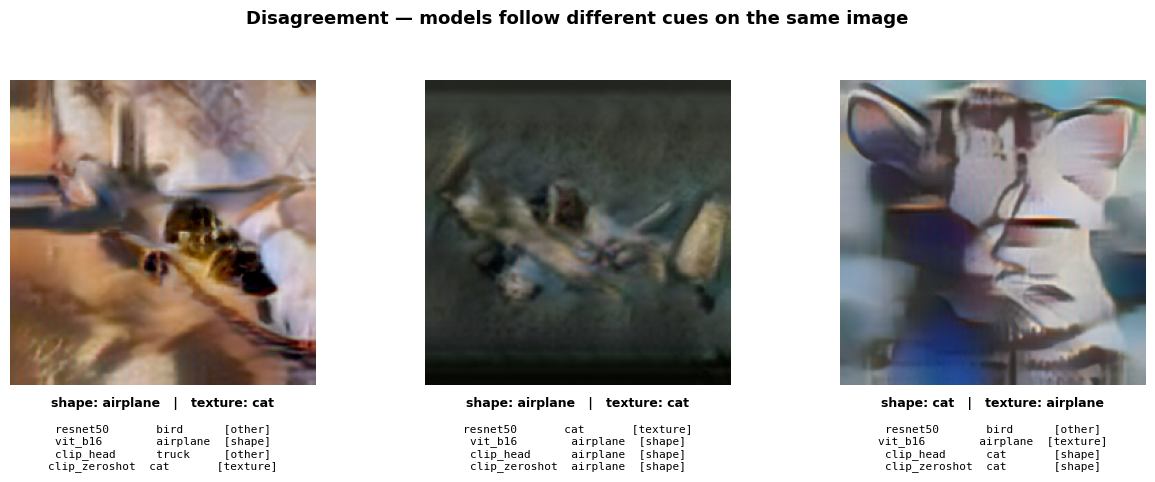

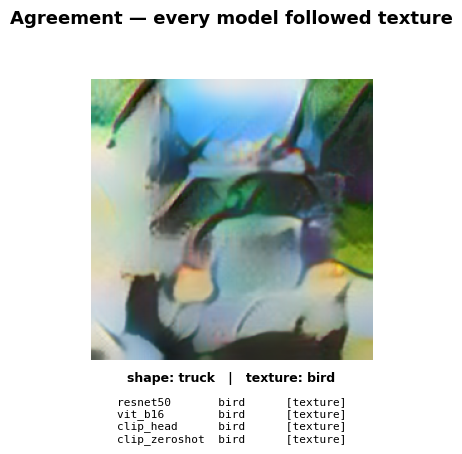

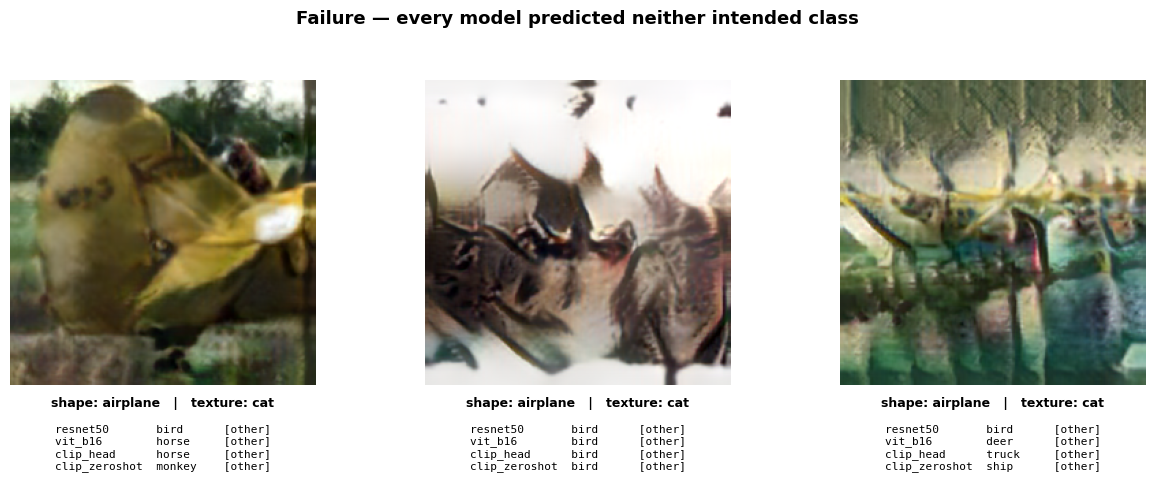

In [9]:
# %% Cell 9: show and record the examples
def show_examples(indices, title, n=3, save_name=None):
    indices = indices[:n]
    if not indices:
        print(f"(no examples for: {title})"); return []

    fig, axes = plt.subplots(1, len(indices), figsize=(4.2 * len(indices), 5.4))
    if len(indices) == 1: axes = [axes]

    records = []
    for ax, i in zip(axes, indices):
        ax.imshow(imgs_kept[i].permute(1, 2, 0).numpy())
        ax.axis('off')
        p = plan_kept[i]

        header = f"shape: {class_names[shape_labels[i]]}   |   texture: {class_names[texture_labels[i]]}"
        rows = []
        rec = {"pair": p["pair"], "shape_class": class_names[shape_labels[i]],
               "texture_class": class_names[texture_labels[i]], "predictions": {}}
        for m in model_order:
            pr = all_preds[m][i]
            v = verdict(pr, shape_labels[i], texture_labels[i])
            rows.append(f"{m:<14} {class_names[pr]:<9} [{v}]")
            rec["predictions"][m] = {"predicted": class_names[pr], "verdict": v}

        # caption goes BELOW the image, monospaced so columns line up
        ax.text(0.5, -0.04, header, transform=ax.transAxes, ha='center', va='top',
                fontsize=9, fontweight='bold')
        ax.text(0.5, -0.13, "\n".join(rows), transform=ax.transAxes, ha='center', va='top',
                fontsize=8, family='monospace')
        records.append(rec)

    fig.suptitle(title, fontsize=13, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.22, 1, 0.94])   # leaves room for captions below and title above

    if save_name:
        fig.savefig(f"../../report/figures/{save_name}.png", dpi=200, bbox_inches='tight')
    plt.show()
    return records

examples = {}
examples["disagreement"] = show_examples(cases["split_shape_vs_texture"],
    "Disagreement — models follow different cues on the same image",
    save_name="cue_conflict_disagreement")
examples["all_texture"] = show_examples(cases["all_texture"],
    "Agreement — every model followed texture",
    save_name="cue_conflict_all_texture")
examples["all_other"] = show_examples(cases["all_other"],
    "Failure — every model predicted neither intended class",
    save_name="cue_conflict_failures")

save_results({"alpha": alpha_ex, "examples": examples}, "../results/cue_conflict_examples.json")